### Легенда
В контакт-центре внедрили новый скрипт разговора для операторов.
#### Задача:
1. Проверить качество A/B-эксперимента и баланс групп
2. Описать различия между группами
3. Оценить статистическую значимость различий
4. Оценить размер и неопределённость эффекта
5. Сформулировать выводы, ограничения и условия для принятия решения

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.proportion import proportions_ztest

## Чтение и первичный осмотр данных

In [2]:
df = pd.read_csv(r'data/ab_test_results.csv')
print(f'Количество строк :{df.shape[0]} \nКоличество столбцов :{df.shape[1]}')
df.head(5)

Количество строк :2000 
Количество столбцов :7


,date,hour,group,operator_experience,fcr,aht_sec,day_of_week
0,2026-08-07,8,B,middle,1,303.0,4
1,2026-08-04,14,A,senior,0,324.0,1
2,2026-08-13,15,B,middle,1,335.0,3
3,2026-08-11,10,B,senior,1,299.0,1
4,2026-08-08,10,A,junior,1,347.0,5


## Шаг 1 — БАЛАНС ГРУПП
- [x] по количеству наблюдений
- [x] по дням недели
- [x] по опыту(грейду сотрудников)
- [x] по часам
- [x] по датам

In [3]:
# Проверка распределения по количеству наблюдений
print(50*'=')
print('Сбалансированность групп по колличеству наблюдений'.center(50))
print(50*'-')
print(df['group'].value_counts(normalize=True).round(4) * 100)

Сбалансированность групп по колличеству наблюдений
--------------------------------------------------
group
B    51.15
A    48.85
Name: proportion, dtype: float64


Группы близки по размеру

In [4]:
# Проверка распределения по дням недели
pivot_day_of_week = df.pivot_table(
    index='group',
    columns='day_of_week',
    values='operator_experience',
    aggfunc='count'
)
pivot_day_of_week
# Проверка баланса по дням недели через Хи тест (таблица сопряженности)
chi2, p_value, dof, expected = chi2_contingency(pivot_day_of_week)
print(50*'=')
print('Хи тест по дням недели'.center(50))
print(50*'-')
print(f"p-value для дней недели: {p_value:.2f}")


# Проверяем сбалансированность групп по Грейдам сотрудников
operator_experience = df.pivot_table(
    index='group',
    columns='operator_experience',
    values='date',
    aggfunc='count'
)
chi2, p_value, dof, expected = chi2_contingency(operator_experience)
print(50*'=')
print('Хи тест по грейдам'.center(50))
print(50*'-')
print(f"p-value для грейдов: {p_value:.2f}")


# Проверяем сбалансированность групп по часам
hour_group = df.pivot_table(
    index='group',
    columns='hour',
    values='date',
    aggfunc='count'
)
chi2, p_value, dof, expected = chi2_contingency(hour_group)
print(50*'=')
print('Хи тест по часам'.center(50))
print(50*'-')
print(f"p-value для часов: {p_value:.2f}")


# Проверяем сбалансированность групп по датам
date_group = df.pivot_table(
    index='group',
    columns='date',
    values='hour',
    aggfunc='count'
)
chi2, p_value, dof, expected = chi2_contingency(date_group)

print(50*'=')
print('Хи тест по датам'.center(50))
print(50*'-')
print(f"p-value для дат: {p_value:.2f}")

              Хи тест по дням недели              
--------------------------------------------------
p-value для дней недели: 0.86
                Хи тест по грейдам                
--------------------------------------------------
p-value для грейдов: 0.64
                 Хи тест по часам                 
--------------------------------------------------
p-value для часов: 0.15
                 Хи тест по датам                 
--------------------------------------------------
p-value для дат: 0.69


### Вывод:
Статистически значимых различий в распределении проверенных признаков между группами не обнаружено

## Шаг 2 - EDA

Описательная статистика по группам:
        fcr              aht_sec              
       mean median   std    mean median    std
group                                         
A      0.63    1.0  0.48  311.32  310.0  34.98
B      0.67    1.0  0.47  295.17  296.0  34.65


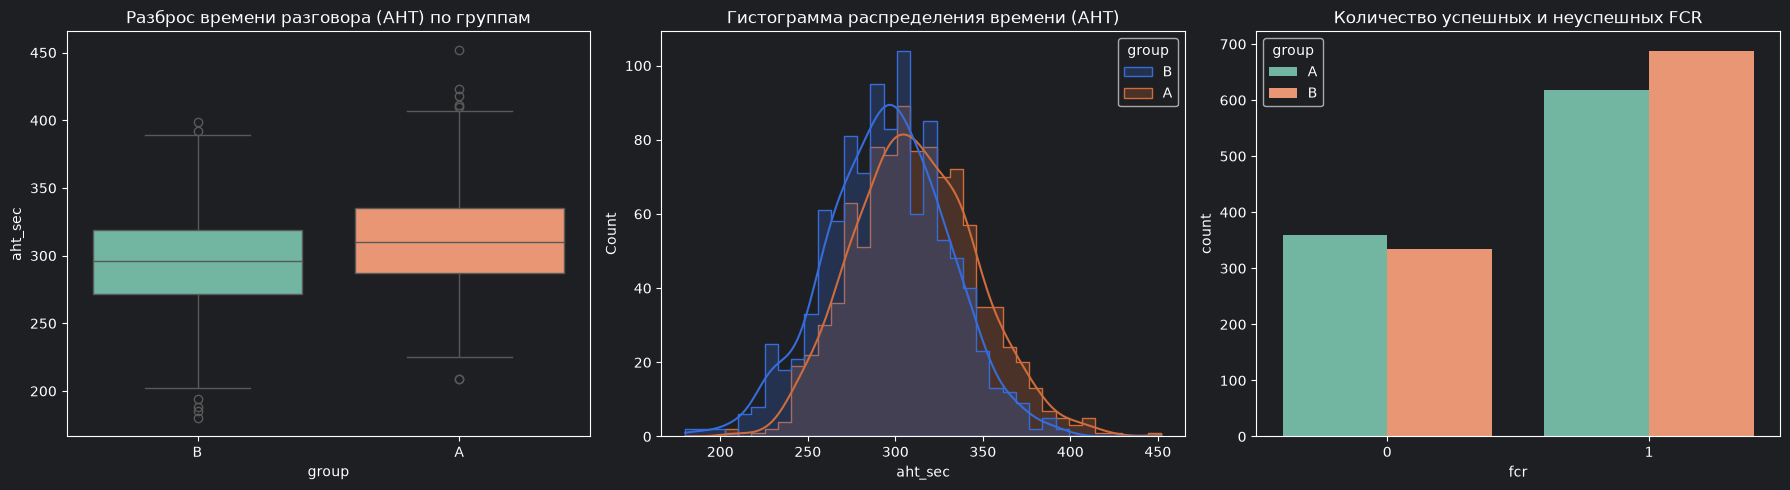

In [5]:
# Считаем среднее, медиану, стандартное отклонение по группам
eda_stats = df.groupby('group').agg({
    'fcr': ['mean','median','std'],
    'aht_sec':['mean','median','std']
}).round(2)
print("Описательная статистика по группам:")
print(eda_stats)

# Настраиваем окно для 4 графиков (2х2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot для AHT — ТЕПЕРЬ БЕЗ ПРЕДУПРЕЖДЕНИЙ
sns.boxplot(data=df, x='group', y='aht_sec', hue='group',ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Разброс времени разговора (AHT) по группам')

# 2. Гистограмма распределения AHT
sns.histplot(data=df, x='aht_sec', hue='group', kde=True, ax=axes[1], element='step', common_norm=False)
axes[1].set_title('Гистограмма распределения времени (AHT)')

# 3. Гистограмма распределения FCR
sns.countplot(data=df, x='fcr', hue='group', ax=axes[2], palette='Set2')
axes[2].set_title('Количество успешных и неуспешных FCR')

plt.tight_layout()
plt.show()

### Вывод по блоку «Описательная статистика и визуализация»

Перед тем как запускать статистические тесты, просматриваем графики и рассчитал базовые показатели (среднее и медиану). Результаты:

1. **Метрика качества решения (FCR):**
   * В контрольной группе А (старый скрипт) средний FCR равен **63%**, а в целевой группе B (новый скрипт) — **67%**. Разница составляет **4 процентных пункта** в пользу нового скрипта.
   * На графике (countplot) визуально видно, что у группы B успешных звонков (единиц) чуть больше, а неуспешных (нулей) — меньше. На первый взгляд кажется, что новый скрипт помогает решать вопросы лучше, но эту разницу еще нужно проверить тестом на случайность.
   * *Примечание:* Медиана в обеих группах равна 1.0, а стандартное отклонение примерно одинаковое (~0.47), так как метрика состоит только из нулей и единиц, и эти показатели здесь не дают важной информации.

2. **Метрика времени разговора (AHT):**
   * Новый скрипт заметно снизил время диалога. В среднем операторы группы B говорят быстрее на **16,15 секунд** (295,17 сек против 311,32 сек в группе А).
   * Если смотреть на медиану (время «типичного» звонка), то группа B также быстрее группы А на **14 секунд** (296 сек против 310 сек). Среднее и медианное значения AHT в группе B ниже, чем в группе A, что указывает на устойчивое различие не только в среднем значении.
   * Стандартное отклонение (разброс данных) в обеих группах почти одинаковое (около 35 секунд). Стандартное отклонение в обеих группах сопоставимо, поэтому разброс AHT существенно не различается. Среднее и медианное значения AHT в группе B ниже, чем в группе A.
   * На графиках видно, что распределение AHT в группе B смещено в сторону меньших значений относительно группы A. Также у группы B появилось больше аномально коротких звонков (меньше 200 сек), а у группы А, наоборот, чаще зависали долгие разговоры (дольше 400 сек).

**Итог:** Первичный анализ показывает снижение AHT и наблюдаемое увеличение FCR. Далее статистический тест позволит оценить, насколько эти различия согласуются с нулевой гипотезой.

## Шаг 3 - ГИПОТЕЗЫ

Перед запуском статистических тестов я сформулировал Нулевые ($H_0$) и Альтернативные ($H_1$) гипотезы для каждой метрики.

#### 1. Метрика качества решения (FCR)
*   **$H_0$ доля успешных обращений одинаковая в A и B.**
*   **$H_1$ доля успешных обращений различается.**

#### 2. Метрика времени разговора (AHT)
*   **$H_0$ средний AHT одинаков в A и B.**
*   **$H_1$ средний AHT различается.**

## Шаг 4 — ВЫБОР ТЕСТА

| Метрика | Тип данных  | Сравниваем    | Метод      -               |
| ------- | ----------- | ------------- | ------------------------ |
| FCR     | бинарная    | доли A и B    | z-тест для двух пропорций |
| AHT     | непрерывная | средние A и B | тест Велча                |


Пояснения:

- FCR принимает значения 0/1, поэтому сравниваем две пропорции.
- AHT измеряется в секундах, поэтому сравниваем два средних значения.
Для AHT используем тест Велча, поскольку он не требует предположения о равенстве дисперсий.


## Шаг 5 — ОСНОВНОЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ

In [6]:
# Таблица количества успешных и неуспешных обращений по группам
fcr_counts = df.pivot_table(
    index='group',
    columns='fcr',
    values='date',
    aggfunc='count'
)
fcr_counts

fcr,0,1
group,,
A,359,618
B,335,688


In [7]:
# 1. Анализ метрики FCR
successes = fcr_counts[1]
sample_sizes = fcr_counts.sum(axis=1)

z_stat, p_value_fcr = proportions_ztest(
    count=successes,
    nobs=sample_sizes,
    alternative='two-sided'
)
# Подготовка данных для расчета ДИ(доверительного интервала)
df_ci = df.groupby('group').agg(
    count=('date','count'),
    fcr=('fcr','mean')
)
p_a = df_ci.loc['A','fcr']
p_b = df_ci.loc['B','fcr']
n_a = df_ci.loc['A','count']
n_b = df_ci.loc['B','count']
# Расчет ДИ для разности долей
difference_fcr = p_b - p_a
se_fcr = ((p_a*(1-p_a)/n_a) + (p_b*(1-p_b)/n_b)) ** 0.5

lower_fcr = difference_fcr - 1.96*se_fcr
upper_fcr = difference_fcr + 1.96*se_fcr
# Вывод результатов FCR
print("=== РЕЗУЛЬТАТЫ ДЛЯ FCR ===")
print(f'z_stat_FCR  = {z_stat:.4f}')
print(f'p_value_FCR = {p_value_fcr:.4f}')
print(f"Эффект (разница долей): {difference_fcr*100:+.2f} п.п.")
print(f"95% ДИ для FCR: [{lower_fcr*100:.2f} п.п. , {upper_fcr*100:.2f} п.п.]\n")
# 2. АНАЛИЗ МЕТРИКИ AHT
# # Выделяем группы для AHT
aht_a = df[df['group']=='A']['aht_sec']
aht_b = df[df['group']=='B']['aht_sec']
t_stat, p_value_aht = ttest_ind(aht_a,aht_b,equal_var=False)
# Точечная разница средних
difference_aht = aht_b.mean() - aht_a.mean()
# Считаем точные объемы выборок именно для этой метрики
n_a_aht = aht_a.count()
n_b_aht = aht_b.count()
# Стандартная ошибка для разности средних (формула Велча)
se_aht = ((aht_a.var() / n_a_aht) + (aht_b.var() / n_b_aht)) ** 0.5
# 95% Доверительный интервал
lower_aht = difference_aht - 1.96 * se_aht
upper_aht = difference_aht + 1.96 * se_aht
# Вывод результатов AHT
print("=== РЕЗУЛЬТАТЫ ДЛЯ AHT ===")
print(f't_stat_AHT  = {t_stat:.4f}')
print(f'p_value_AHT = {p_value_aht:.2e}')
print(f"Эффект (разница средних): {difference_aht:.2f} сек.")
print(f"95% ДИ для AHT: [{lower_aht:.2f} сек. , {upper_aht:.2f} сек.]")

=== РЕЗУЛЬТАТЫ ДЛЯ FCR ===
z_stat_FCR  = -1.8777
p_value_FCR = 0.0604
Эффект (разница долей): +4.00 п.п.
95% ДИ для FCR: [-0.17 п.п. , 8.17 п.п.]

=== РЕЗУЛЬТАТЫ ДЛЯ AHT ===
t_stat_AHT  = 10.3683
p_value_AHT = 1.44e-24
Эффект (разница средних): -16.15 сек.
95% ДИ для AHT: [-19.20 сек. , -13.10 сек.]


In [8]:
diff_group  = df.pivot_table(
    index='group',
    values=['fcr','aht_sec'],
    aggfunc='mean'
).reset_index()
script = {'A':'А - Старый скрипт',
          'B':'B - Новый скрипт',}

diff_group = diff_group.set_index('group').T
diff_group = diff_group.rename(columns=script)
diff_group['Изменение'] = diff_group['B - Новый скрипт'] - diff_group['А - Старый скрипт']
diff_group['Изменение (доля)'] = (diff_group['B - Новый скрипт'] - diff_group['А - Старый скрипт']) / diff_group['А - Старый скрипт']
diff_group = diff_group.rename(index={
    'aht_sec':'AHT',
    'fcr':'FCR'
})
p_value_metrics = {
    'AHT':p_value_aht,
    'FCR':p_value_fcr}
diff_group['p_value'] = p_value_metrics

diff_group

group,А - Старый скрипт,B - Новый скрипт,Изменение,Изменение (доля),p_value
AHT,311.318321,295.169110,-16.149211,-0.051874,1.439647e-24
FCR,0.632549,0.672532,0.039983,0.063210,6.042246e-02


## По результатам A/B-теста после внедрения нового скрипта наблюдаются два изменения.

**AHT снизился на 16.15 секунды:** среднее время обработки диалога в группе B составило 295.17 сек. против 311.32 сек. в группе A. Полученная разница статистически значима (p ≈ 1.44 × 10⁻²⁴; 95% ДИ для разницы: от −19.20 до −13.10 сек.), поэтому у нас есть статистические основания считать наблюдаемое снижение AHT реальным эффектом.

**FCR увеличился на 4.00 п.п.:** 67.25% в группе B против 63.25% в группе A. Однако полученная разница не достигла статистической значимости при α = 0.05 (p ≈ 0.0604; 95% ДИ: от −0.17 до +8.17 п.п.). Поэтому на основании текущего эксперимента недостаточно оснований утверждать, что новый скрипт действительно изменяет FCR.

Таким образом, в рамках проведённого A/B-теста наиболее уверенно подтверждается снижение AHT. Увеличение FCR наблюдается, но его наличие пока нельзя статистически подтвердить. Это не означает отсутствия эффекта FCR — текущие данные просто не дают достаточных оснований сделать такой вывод.


**Важно!**
ДИ для AHT рассчитан с использованием нормального приближения (z = 1.96), что обосновано большими объёмами выборок (n ≈ 1000 в каждой группе); при таких n t-квантиль Уэлча практически совпадает с 1.96

## Что нужно учитывать при оценке результатов (Ограничения)

Несмотря на чёткие цифры, у нашего эксперимента есть два важных ограничения, которые необходимо учитывать при интерпретации результатов.

### 1. Нет ID оператора

В данных нет идентификатора конкретного сотрудника. Поэтому мы не можем проверить, участвовали ли одни и те же операторы в обеих группах, а также насколько состав участников был сопоставим на уровне отдельных сотрудников.

**Почему это важно:** если одни и те же сотрудники могли появляться в обеих группах, это может влиять на независимость наблюдений и интерпретацию результата.

### 2. Не анализировали результаты отдельно по грейдам

В данных есть информация об опыте операторов, однако в основном анализе мы рассматривали всех операторов вместе и не проверяли результаты отдельно по грейдам.

**Почему это важно:** эффект нового скрипта может различаться в зависимости от уровня опыта сотрудника. Например, он может сильнее помогать менее опытным операторам и практически не менять результаты более опытных. Общий показатель по всем операторам этого различия не показывает.

### 3. Проверка баланса выполнена по доступным ковариатам; сравнение групп по baseline-значениям метрик невозможно из-за отсутствия pre-period
